# Adversarial Patch Generation - Collusion

This notebook uses a given dataset to generate an adversarial patch which is classified as a chosen class. 

## Environment

ART should be compatible with Python 3.9, 3.10 and 3.11 (https://github.com/Trusted-AI/adversarial-robustness-toolbox)

Lightning AI conda 3.9.20 Kernel and Environment 3.9.0 

Or locally Python 3.9.16

We install ART using the flag -e so we can use our own modified version, which can be cloned from: https://github.com/xHascox/adversarial-robustness-toolbox

In [1]:
%pip install -e ../adversarial-robustness-toolbox

Obtaining file:///teamspace/studios/this_studio/adversarial-robustness-toolbox
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for adversarial-robustness-toolbox (pyproject.toml) ... |

done
  Created wheel for adversarial-robustness-toolbox: filename=adversarial_robustness_toolbox-1.18.2-0.editable-py3-none-any.whl size=7433 sha256=d3ef6573c5e5144dcfb2c3698bc4ad19f8019ae772e84ee8dc79fc4ba1d920b8
  Stored in directory: /tmp/pip-ephem-wheel-cache-hj9zm9lx/wheels/03/61/09/794ca0dc4b448c209119fd654093de6dc9a9a5932f136fd39c
Successfully built adversarial-robustness-toolbox
  Attempting uninstall: adversarial-robustness-toolbox
    Found existing installation: adversarial-robustness-toolbox 1.18.2
    Uninstalling adversarial-robustness-toolbox-1.18.2:
      Successfully uninstalled adversarial-robustness-toolbox-1.18.2
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# ART - Adversarial Patch - PyTorch - YOLO

This Notebook is based on: https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/notebooks/adversarial_patch/attack_adversarial_patch_pytorch_yolo.ipynb

In [3]:
import art.attacks.evasion
from art.estimators.object_detection.pytorch_yolo import PyTorchYolo
from art.attacks.evasion import AdversarialPatchPyTorch
art.attacks.evasion.__file__  # Making sure we use our version of ART

'/teamspace/studios/this_studio/adversarial-robustness-toolbox/art/attacks/evasion/__init__.py'

## Patch Generation

In [4]:
import yolov5
from yolov5.utils.loss import ComputeLoss

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import requests
import io
from io import BytesIO
import zipfile

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torchvision.transforms import transforms
from tqdm import tqdm
from PIL import Image

import cv2
import matplotlib
import matplotlib.pyplot as plt


plt.style.use('ggplot')
matplotlib.use('Agg')  # Use the 'Agg' backend for headless mode

#matplotlib.use( 'tkagg' )
%matplotlib inline

Yolov5 classes etc.: https://github.com/ultralytics/yolov5/blob/master/data/coco.yaml

In [5]:
OBJECT_CATEGORY_NAMES = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
        'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
        'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
        'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
        'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 
        'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 
        'teddy bear', 'hair drier', 'toothbrush']  # These are the classes that Yolov5 can detect

In [6]:
OBJECT_CATEGORY_NAMES.index("car")

2

In [7]:
def extract_predictions(predictions_, conf_thresh=0, n_boxes=5, classes=[]):
    """
    Filters the predictions obtained from a model by their confidence and classes

    predictions_: The predictions from a model
    conf_thresh: Min. score for predictions to be included (float)
    n_boxes: Max. number of prediction to keep (takes the ones with highest score) (int)
    classes: classes to keep (all if empty) (list)

    Returns a tuple of (classes, boxes, scores) of the detections
    """
    if len(predictions_["labels"]) < 1:  # If there are no detections, return empty lists
        return [], [], []
    predictions_class = [OBJECT_CATEGORY_NAMES[i] for i in list(predictions_["labels"])]  # For each prediction, get the predicted class
    predictions_boxes = [[(i[0], i[1]), (i[2], i[3])] for i in list(predictions_["boxes"])]  # Get the predicted bounding boxes
    predictions_score = list(predictions_["scores"])  # Get the prediction score

    predictions_t = sorted(range(len(predictions_score)), key=lambda i: predictions_score[i], reverse=True)  # Sort the prediction indices by their score

    # Put the other lists in the same order, by descending prediction score
    predictions_boxes = [predictions_boxes[i] for i in predictions_t]
    predictions_class = [predictions_class[i] for i in predictions_t]
    predictions_scores = [predictions_score[i] for i in predictions_t]
    if classes:  # only keep the n_boxes best detections of the specified classes, if they are above the confidence threshold
        predictions_boxes_n = [e for e, c, s in zip(predictions_boxes, predictions_class, predictions_scores) if c in classes and s >= conf_thresh][:n_boxes]
        predictions_class_n = [e for e, s in zip(predictions_class, predictions_scores) if e in classes and s >= conf_thresh][:n_boxes]
        predictions_scores_n = [e for e, c in zip(predictions_scores, predictions_class) if c in classes and e >= conf_thresh][:n_boxes]
    else:  # only keep the n_boxes best detections
        predictions_boxes_n = predictions_boxes[:n_boxes]
        predictions_class_n = predictions_class[:n_boxes]
        predictions_scores_n = predictions_scores[:n_boxes]

    return predictions_class_n, predictions_boxes_n, predictions_scores_n


def plot_image_with_boxes(img, boxes, pred_cls, title, scores, color=(0,255,0), colordict={}):
    """
    Visualizes an image with the detected object boxes

    img: Image to plot
    boxes: Prediction boxes (from extract_predictions)
    pred_cls: Class (from extract_predictions)
    title: The plot title (str)
    scores: Score (from extract_predictions)
    color: Default color value for the boxes (tuple)
    colordict: Dictionary with box colors for some classes (dict) like {"car":(255,0,0)}
    """
    text_size = 1
    text_th = 3
    rect_th = 2

    for i in range(len(boxes)):
        cv2.rectangle(img, (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1])),
                      color=colordict.get(pred_cls[i], color), thickness=rect_th)
        # Write the prediction class
        cv2.putText(img, pred_cls[i]+" "+f"{scores[i]:.2f}", (int(boxes[i][0][0]), int(boxes[i][0][1])), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    colordict.get(pred_cls[i], color), thickness=text_th)

    plt.figure()
    plt.axis("off")
    plt.title(title)
    plt.imshow(img.astype(np.uint8), interpolation="nearest")



Check available GPU:

In [8]:
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")
else:
    print("No GPU found.")

GPU Name: NVIDIA L4
GPU Count: 1


Define the model to attack

In [9]:
NUMBER_CHANNELS = 3
INPUT_SHAPE = (NUMBER_CHANNELS, 1024, 1024) # For some reason, this only really works for square images, (512, 1024) used to work

In [10]:
class Yolo(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.model.hyp = {'box': 0.05,
                        'obj': 1.0,
                        'cls': 0.5,
                        'anchor_t': 4.0,
                        'cls_pw': 1.0,
                        'obj_pw': 1.0,
                        'fl_gamma': 0.0
                        }
        self.compute_loss = ComputeLoss(self.model.model.model)

    def forward(self, x, targets=None):
        if self.training:
            outputs = self.model.model.model(x)
            loss, loss_items = self.compute_loss(outputs, targets)
            loss_components_dict = {"loss_total": loss}
            loss_components_dict['loss_box'] = loss_items[0]
            loss_components_dict['loss_obj'] = loss_items[1]
            loss_components_dict['loss_cls'] = loss_items[2]
            return loss_components_dict
        else:
            return self.model(x)

model = yolov5.load('yolov5s.pt')
#model2 = yolov5.load('best.pt')
#model = torch.hub.load('ultralytics/yolov5', 'custom', 'best.pt')

model = Yolo(model)

detector = PyTorchYolo(model=model,
                    device_type='gpu',
                    input_shape=INPUT_SHAPE,
                    clip_values=(0, 255), 
                    attack_losses=("loss_total", "loss_cls",
                                    "loss_box",
                                    "loss_obj"))

Fix the seed

In [11]:
# Set the seed for randomness
seed = 42

# Set the seed for PyTorch
torch.manual_seed(seed)

# If you are using CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for all GPUs

# Set the seed for NumPy
np.random.seed(seed)

# Set the seed for Python's built-in random module
random.seed(seed)

In [12]:
# directory containing the training images
DATASET_URL = "https://storage.googleapis.com/weebit-shared/ParkingCrossingPedestrian.zip"
TRAINING_DATASET_DIR = "D:\CarlaGarageData\PatchDataset"
LARGE_DATASET = True
DATASET_CUTOFF_GENERATE = 0
DATASET_CUTOFF = 40
# './train img/'
# "D:\CarlaGarageData\PatchDataset"

In [13]:
"""
Here, we download the Patch Dataset from remote if it does not already exist on disk, as specified by TRAINING_DATASET_DIR.
"""
# Define the folder and URL
folder_path = TRAINING_DATASET_DIR
zip_url = DATASET_URL

# Check if folder exists
if not os.path.exists(folder_path):
    print(f"{folder_path} does not exist. Downloading ZIP from {zip_url}...")

    # Stream the download and write to a file
    with requests.get(zip_url, stream=True) as response:
        response.raise_for_status()  # Check for HTTP errors
        total_size = int(response.headers.get('content-length', 0))
        chunk_size = 1024 * 1024 * 128 # 128 MB

        # Write to a temp file for large size
        with tqdm(total=total_size//(1024*1024), unit='MB', unit_scale=True, desc='Downloading') as progress_bar:
            temp_zip_path = "temp_download.zip"
            with open(temp_zip_path, 'wb') as file:
                for chunk in response.iter_content(chunk_size=chunk_size):
                    if chunk:  # Filter out keep-alive chunks
                        file.write(chunk)
                        progress_bar.update(len(chunk)//(1024*1024))


    # Now extract the ZIP file
    print("Extracting the files...")
    with zipfile.ZipFile(temp_zip_path, 'r') as zip_ref:
        zip_ref.extractall(folder_path)

    # Optionally remove the zip file after extraction
    os.remove(temp_zip_path)
    print(f"Content extracted to {folder_path}.")
else:
    print(f"{folder_path} already exists. No need to download.")

D:\CarlaGarageData\PatchDataset already exists. No need to download.


In [14]:
urls = []

# Iterate over all files and directories in the given path
for root, dirs, files in os.walk(TRAINING_DATASET_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        print(file_path)  # Do something with the file path
        urls+=[file_path]

print("Size of Dataset:", len(urls))

if not DATASET_CUTOFF:
    DATASET_CUTOFF = len(urls)

# Calculate padding, assumes all images in the training set have the same resolution
train_img_height = Image.open(urls[0]).height
padding_top = (INPUT_SHAPE[1] - train_img_height) // 2
padding_bottom = INPUT_SHAPE[1] - train_img_height - padding_top

transform = transforms.Compose([
        #transforms.Resize(INPUT_SHAPE[1], interpolation=transforms.InterpolationMode.BICUBIC),
        #transforms.CenterCrop(INPUT_SHAPE[1]),
        transforms.Pad((0, padding_top, 0, padding_bottom)),
        transforms.ToTensor()
    ])

training_images = []
#for url in urls[:DATASET_CUTOFF]:
for url in random.sample(urls, DATASET_CUTOFF if DATASET_CUTOFF > 0 and DATASET_CUTOFF <= len(urls) else len(urls)):
    im = Image.open(url)
    im = transform(im).numpy()
    training_images.append(im)

training_images = np.array(training_images)*255

if not LARGE_DATASET:
    training_images_for_generation = training_images
else:
    training_images_for_generation = urls

if DATASET_CUTOFF_GENERATE:
    training_images_for_generation = training_images_for_generation[:DATASET_CUTOFF_GENERATE]

print("After cutoff for Generation:", len(training_images_for_generation))

D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0000.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0001.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0002.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0003.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0004.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0005.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0006.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0007.jpg
D:\CarlaGarageData\PatchDataset/ParkingCrossingPedestrian/Town12_Rep0_1059_0_route0_11_08_16_20_04/rgb/0

D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0000.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0001.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0002.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0003.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0004.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0005.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0006.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0007.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town12_Rep0_3666_1_route0_11_09_09_56_07/rgb/0008.jpg
D:\CarlaGarageData\PatchDataset/PedestrianCrossing/Town

In [15]:
def filter_boxes(predictions, conf_thresh): # TODO WHY IS THIS NEEDED?
    dictionary = {}

    boxes_list = []
    scores_list = []
    labels_list = []

    for i in range(len(predictions[0]["boxes"])):
        score = predictions[0]["scores"][i]
        if score >= conf_thresh:
            boxes_list.append(predictions[0]["boxes"][i])
            scores_list.append(predictions[0]["scores"][[i]])
            labels_list.append(predictions[0]["labels"][[i]])

    #dictionary["boxes"] = np.vstack(boxes_list)
    if boxes_list:  # Check if boxes_list is not empty
        dictionary["boxes"] = np.vstack(boxes_list)
        dictionary["scores"] = np.hstack(scores_list)
        dictionary["labels"] = np.hstack(labels_list)
    else:
        dictionary["boxes"] = np.empty((0,))  # Assign an empty array if boxes_list is empty
        dictionary["scores"] = np.empty((0,))
        dictionary["labels"] = np.empty((0,))

    y = [dictionary]

    return y

dets = detector.predict(training_images)
#dets2 = detector2.predict(coco_images) 

y = [filter_boxes([t], 0.8)[0] for t in dets]

In [16]:
y[-1]

{'boxes': array([[     138.03,       499.4,      172.47,      534.62],
        [     137.77,      499.55,      172.75,      534.23],
        [     673.05,      493.02,      726.37,       545.6],
        [     673.84,      492.57,      726.28,      543.56],
        [     674.08,      493.25,      725.95,      545.43],
        [     674.57,      492.69,      726.18,      543.36],
        [      137.8,      498.66,      173.83,      534.24],
        [     672.98,       492.3,      725.19,      543.84],
        [     138.33,      498.09,      173.79,      533.57],
        [     138.07,      497.79,      173.24,      534.06],
        [     673.35,      492.46,       725.5,      543.49],
        [     673.67,      492.34,      724.62,      543.11],
        [     759.61,      529.85,      849.84,      565.73],
        [        247,       527.2,      311.36,       625.3],
        [     247.13,      528.07,      310.97,      624.51],
        [     320.54,      564.89,      362.83,      633.83],

In [17]:

#- boxes [N, 4]: the boxes in [x1, y1, x2, y2] format, with 0 <= x1 < x2 <= W and 0 <= y1 < y2 <= H.

In [18]:
GENERATE = True
DISGUISE_PATH = "./disguises/mountain_1.jpg"
USE_PRETRAINED = None#"patch_as_image_stop_sign_lr_0.01_200it.png"
USE_PRETRAINED = "patch_as_image_stop_sign_contrast_1.png"
USE_PRETRAINED = None
#USE_PRETRAINED = DISGUISE_PATH
USE_PRETRAINED = "patch_as_image.png"#DISGUISE_PATH
#USE_PRETRAINED = "patch_stop_dist_PD_128_16e_split.png"

PATCH_PATH = "patch_as_image.png"
#PATCH_PATH = "patch_as_image_stop_dist_50k_small_0.02.png"



In [19]:
rotation_max=5#20#20 # 0.0 # degrees
scale_min=0.05#0.03 # 0.05
scale_max=0.10
distortion_scale_max=0.2#.2#.3 # [0,1]
learning_rate=0.01#0.001 #1.99 # 0.003
max_epochs=1#0#0000 #1000 # 50000 gives a good result
max_steps = 0
if not GENERATE:
    max_epochs = 1
    max_steps = 1
batch_size=8 # For 2080 TI: 13, similar speed to L4 with batch size 10
patch_type="square"
optimizer="pgd" # pgd and Adam
patch_location=(400, 200) # TODO
targeted = True
patch_shape=(3, 512, 512)#(3, 200, 200)
contrast_min = 0.8#0.4 physical
contrast_max = 0.95#0.7 physical
disguise = np.array(Image.open(DISGUISE_PATH).resize(patch_shape[1:]))
disguise = disguise.transpose(2,0,1)
#disguise = None
disguise_distance_factor = 1/2000#000
# 0.0005 was too much for stop mountain
split = False
gap_size = 30
#- boxes [N, 4]: the boxes in [x1, y1, x2, y2] format, with 0 <= x1 < x2 <= W and 0 <= y1 < y2 <= H.

synthetic_y = {'boxes': np.array([[     patch_location[0],      patch_location[1],      patch_location[0]+patch_shape[1],      patch_location[1]+patch_shape[2]]], dtype=np.float32),
 'scores': np.array([    1], dtype=np.float32),
 'labels': np.array([OBJECT_CATEGORY_NAMES.index("stop sign")])} # person = 0, stop sign = 11, banana = 46

patch_location=None # TODO make it work for fixed location, the scaling fails

print("USING:", detector.device)

pretrained_patch = None
if USE_PRETRAINED:
    pretrained_patch=np.array(Image.open(USE_PRETRAINED).resize(patch_shape[1:]))
    pretrained_patch = pretrained_patch.transpose(2,0,1)

ap = AdversarialPatchPyTorch(estimator=detector, rotation_max=rotation_max, 
                      scale_min=scale_min, scale_max=scale_max, optimizer=optimizer, distortion_scale_max=distortion_scale_max, 
                      learning_rate=learning_rate, max_epochs=max_epochs, max_steps=max_steps, batch_size=batch_size, summary_writer=False, contrast_min = contrast_min, contrast_max = contrast_max,# TODO
                      patch_shape=patch_shape, patch_type=patch_type, verbose=True, targeted=targeted, patch_location=patch_location, pretrained_patch=pretrained_patch, disguise=disguise, disguise_distance_factor=disguise_distance_factor, split=split, gap_size=gap_size) # TODO

if GENERATE:
    patch, patch_mask, loss = ap.generate(x=training_images_for_generation, y=[synthetic_y for i in range(len(training_images_for_generation))], transform=transform,) # 11 is stop sign used as goal target for training the patch (the dataset must then be classified as that)
    #patch, patch_mask = ap.generate(x=training_images_for_generation, y=dets) # untargeted
    # use dets or y with a good threshold as the tarets if using without location TODO
else:
    patch, patch_mask, loss = ap.generate(x=training_images_for_generation, y=[synthetic_y for i in range(len(training_images_for_generation))], transform=transform,) # 11 is stop sign used as goal target for training the patch (the dataset must then be classified as that)
    patch=np.array(Image.open(PATCH_PATH)) # load external patch
    patch = patch.transpose(2,0,1)



USING: cuda:0
USING DEVICE: cuda:0


Training Steps in Epoch 0/1. Previous Loss:   0%|          | 1/6272 [00:01<2:11:08,  1.25s/it]


In [20]:
OBJECT_CATEGORY_NAMES[46]

'banana'

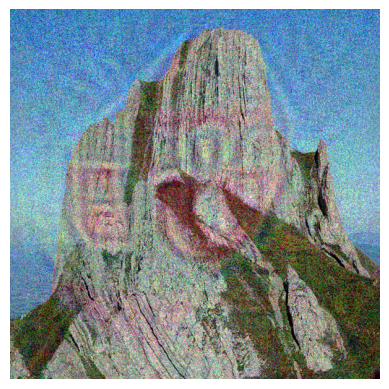

In [21]:
plt.axis("off")
plt.imshow(((patch) * patch_mask).transpose(1,2,0).astype(np.uint8))
plt.show()

In [22]:
loss_history = []
for epoch in loss:
    loss_history.append(sum(epoch))
loss_history = np.array(loss_history)

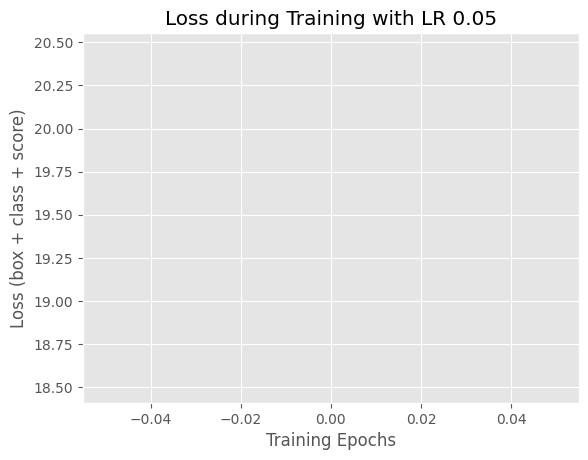

In [23]:
%matplotlib inline
plt.plot(-1*loss_history)
plt.xlabel("Training Epochs")  # Label the implicit x-axis
plt.ylabel("Loss (box + class + score)")
plt.title(f"Loss during Training with LR {learning_rate}")
plt.show()

In [24]:
flat_loss = [batch_loss for epoch in loss for batch_loss in epoch] # flatten the loss history (it contains loss per patch in a list per epoch)
flat_loss = np.array(flat_loss) * -1

# Define the size of the sliding window
k = 10#500

# Calculate the moving average
moving_averages = np.convolve(flat_loss, np.ones(k)/k, mode='valid')

# Indices for the moving average to align with the input list
average_indices = range(k - 1, len(flat_loss))

In [25]:
ap.detailed_loss_history["disguise"]

[26890.703125]

failed to plot avg: x and y must have same first dimension, but have shapes (0,) and (10,)


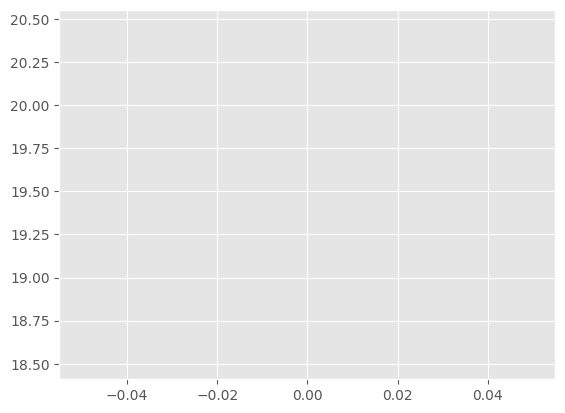

In [26]:
%matplotlib inline
try:
    plt.plot(flat_loss, linewidth=0.5, color=("red"), label="Loss per batch")
    #plt.scatter(range(len(flat_loss)), flat_loss)
    plt.plot(average_indices, moving_averages, linestyle='--', color='blue', linewidth=5, label=f'Moving Average (k={k})')


    plt.xlabel("Training Batches")  # Label the implicit x-axis
    plt.ylabel("Loss (box + class + score + disguise)")
    plt.legend()
    plt.title(f"Loss during Training with LR {learning_rate}")
    plt.show()
except Exception as e:
    print("failed to plot avg:", e)

In [27]:
Image.fromarray(patch.transpose(1,2,0).astype(np.uint8)).save("patch_as_image.png")

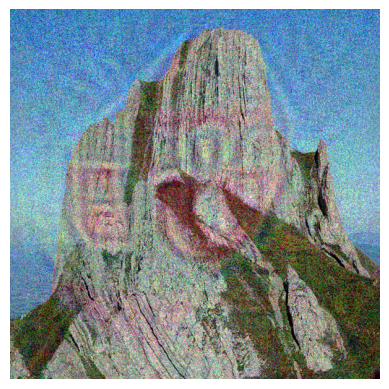

In [28]:
plt.axis("off")
plt.imshow((patch).transpose(1,2,0).astype(np.uint8))
plt.savefig("patch.png", bbox_inches='tight', pad_inches=0)


In [29]:
%matplotlib inline

VAL_PATH = './carla val images'
classes = ["stop sign", "banana", "person", "car"]
n_boxes = 20
colordict =  {"stop sign":(255, 0, 0), "banana": (0,0,255), "car":(200, 0, 200), "person":(0, 200, 200)}
plot_threshold = 0
SKIP = 0

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for all GPUs
np.random.seed(seed)
random.seed(seed)



val_transform = transforms.Compose([
        transforms.Resize((INPUT_SHAPE[1], INPUT_SHAPE[2]), interpolation=transforms.InterpolationMode.BICUBIC),
        #transforms.CenterCrop(INPUT_SHAPE[1]),
        transforms.ToTensor()
    ])

def get_all_file_paths(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

val_files = get_all_file_paths(VAL_PATH)

val_images = []
for file in val_files:
    im = Image.open(file).convert('RGB')

    im = val_transform(im).numpy()
    val_images.append(im)

val_images = np.array(val_images)*255

%matplotlib inline

dets_orig_val = detector.predict(val_images)

for i in range(len(dets_orig_val)):
    if i<SKIP:
        continue
    preds_orig = extract_predictions(dets_orig_val[i], plot_threshold, n_boxes=n_boxes, classes=classes)
    plot_image_with_boxes(img=val_images[i].transpose(1,2,0).copy(), boxes=preds_orig[1], pred_cls=preds_orig[0],
                           title="Predictions on image without patch", scores=preds_orig[2], colordict=colordict)


In [31]:
%matplotlib inline
classes = ["stop sign", "banana", "person", "car"]
#classes = ["stop sign", ]

n_boxes = 40
colordict =  {"stop sign":(255, 0, 0), "banana": (0,0,255), "car":(200, 0, 200), "person":(0, 200, 200)}
plot_threshold = 0
SCALE = scale_max
SKIP = 0

dets_orig = detector.predict(training_images)

patched_images_l = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="left")
dets_l = detector.predict(patched_images_l)

patched_images_r = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=False, half_to_keep="right")
dets_r = detector.predict(patched_images_r)

if split:
    patched_images, _ = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True) # , locations = 
else:
    patched_images = ap.apply_patch(training_images[:], scale=SCALE, patch_external=patch, split=split, split_keep_both=True, return_patch_outlines=True)
dets = detector.predict(patched_images)

for i in range(len(dets)):
    if i<SKIP:
        continue
    preds_orig = extract_predictions(dets_orig[i], plot_threshold, n_boxes=n_boxes, classes=classes)
    plot_image_with_boxes(img=training_images[i].transpose(1,2,0).copy(), boxes=preds_orig[1], pred_cls=preds_orig[0],
                           title="Predictions on image without patch", scores=preds_orig[2], colordict=colordict)
    
    preds = extract_predictions(dets[i], plot_threshold, n_boxes=n_boxes, classes=classes)
    plot_image_with_boxes(img=patched_images[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0],
                           title=f"Predictions on image with both halves patch", scores=preds[2], colordict=colordict)
    preds = extract_predictions(dets_l[i], plot_threshold, n_boxes=n_boxes, classes=classes)
    plot_image_with_boxes(img=patched_images_l[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0],
                           title="Predictions on image with left half of patch", scores=preds[2], colordict=colordict)
    preds = extract_predictions(dets_r[i], plot_threshold, n_boxes=n_boxes, classes=classes)
    plot_image_with_boxes(img=patched_images_r[i].transpose(1,2,0).copy(), boxes=preds[1], pred_cls=preds[0],
                           title="Predictions on image with right half of patch", scores=preds[2], colordict=colordict)
    


/tmp/ipykernel_100481/3648805651.py:59: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
